In [1]:
# imports essential library

import pandas as pd
import numpy as np
from datetime import timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler 

In [2]:
# Loads data

df = pd.read_csv("D:\Projects\Oil price prediction\Crude oil - Crude oil.csv")

# Clean column names
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

df.rename(columns={"Close/Last": "Price"}, inplace=True)
target = "Price"


df.head()

,Price,Volume,Open,High,Low
Date,,,,,
2012-10-30,85.68,NaN,85.68,85.68,85.68
2012-10-31,86.24,192354.0,85.73,87.19,85.61
2012-11-01,87.09,185097.0,86.10,87.42,85.92
2012-11-02,84.86,273619.0,86.91,87.24,84.66
2012-11-05,85.65,185846.0,84.65,85.90,84.34


In [3]:
print(df.columns)

Index(['Price', 'Volume', 'Open', 'High', 'Low'], dtype='object')


In [4]:
print("--- Missing Values Check ---")
print(df.isnull().sum())

--- Missing Values Check ---
Price      0
Volume    31
Open       0
High       0
Low        0
dtype: int64


In [5]:
# Uses Business Days ('B') to avoid empty weekends
df = df.asfreq('B')

# Fill ALL missing values across the whole dataframe
df = df.interpolate(method='linear').ffill().bfill()

print(df.isnull().sum())

Price     0
Volume    0
Open      0
High      0
Low       0
dtype: int64


In [6]:
# Displays data information

print("Data Information:")
print(df.info())

Data Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2609 entries, 2012-10-30 to 2022-10-28
Freq: B
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   2609 non-null   float64
 1   Volume  2609 non-null   float64
 2   Open    2609 non-null   float64
 3   High    2609 non-null   float64
 4   Low     2609 non-null   float64
dtypes: float64(5)
memory usage: 122.3 KB
None


In [7]:
# Descriptive Statistics

print("Summary Statistics:\n", df.describe())

Summary Statistics:
              Price        Volume         Open         High          Low
count  2609.000000  2.609000e+03  2609.000000  2609.000000  2609.000000
mean     65.877930  3.921761e+05    65.884341    66.797923    64.902463
std      22.672475  2.338002e+05    22.651607    22.763845    22.502700
min     -37.630000  1.530000e+02   -37.250000   -35.200000   -40.320000
25%      48.530000  2.220750e+05    48.630000    49.280000    47.770000
50%      59.640000  3.610520e+05    59.570000    60.390000    58.735000
75%      86.900000  5.549410e+05    87.100000    88.290000    86.030000
max     123.700000  1.693652e+06   124.580000   129.440000   120.790000


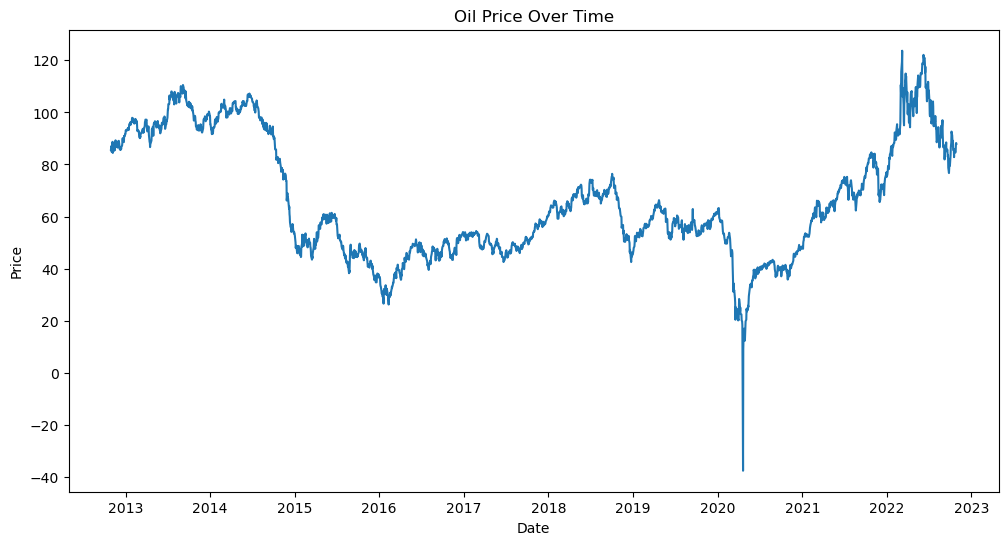

In [8]:
plt.figure(figsize=(12,6))
plt.plot(df['Price'])
plt.title("Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

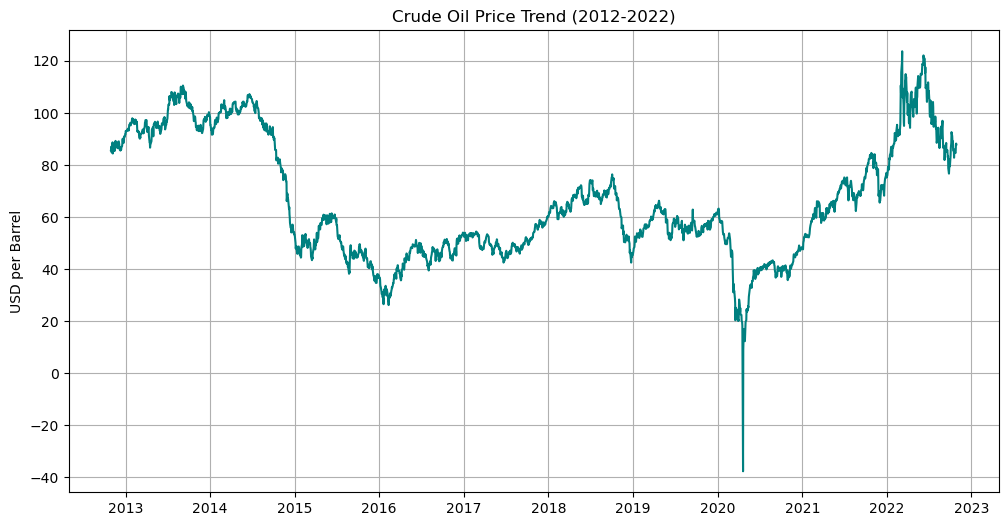

In [9]:
# Visualizing the Price Trend

plt.figure(figsize=(12, 6))
plt.plot(df['Price'], label='Close Price', color='teal')
plt.title('Crude Oil Price Trend (2012-2022)')
plt.ylabel('USD per Barrel')
plt.grid(True)
plt.show()

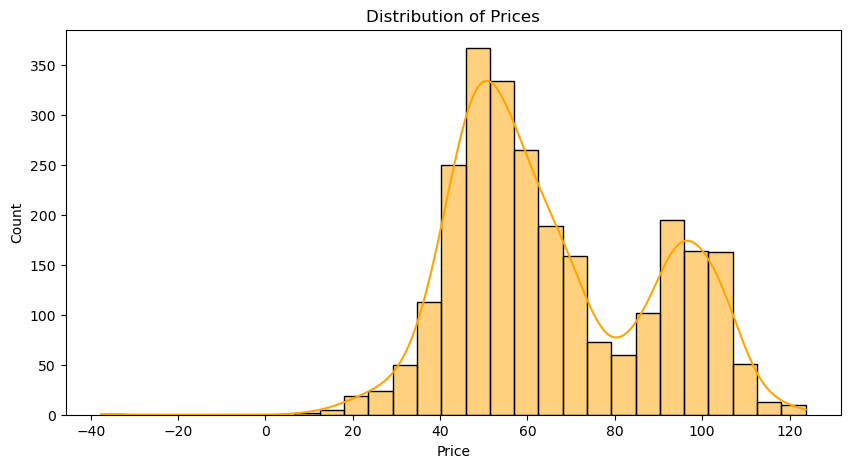

In [10]:
#  Price Distribution & Outliers

plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], kde=True, color='orange')
plt.title('Distribution of Prices')
plt.show()

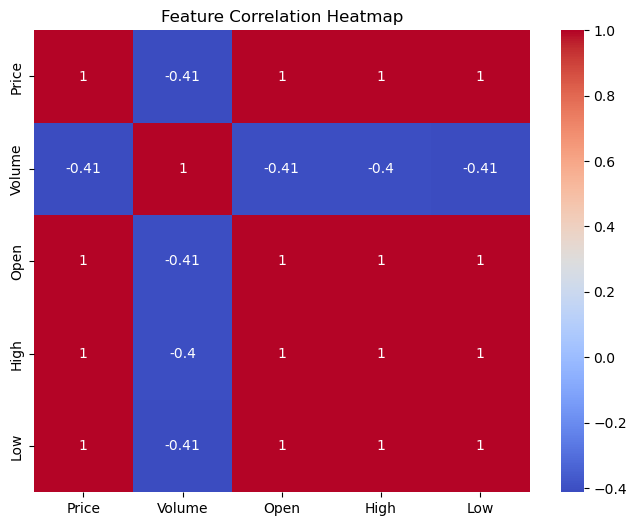

In [11]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [12]:
# Creates features that capture the history of price movements

df['lag_1'] = df['Price'].shift(1)
df['lag_7'] = df['Price'].shift(7)
df['lag_14'] = df['Price'].shift(14)
df['lag_30'] = df['Price'].shift(30)



In [13]:
#  Rolling Statistics of the change

df['rolling_mean_7'] = df['Price'].rolling(7).mean()
df['rolling_mean_30'] = df['Price'].rolling(30).mean()


In [14]:
#  Clean up NaNs

# Dropping rows with NaNs created by shifting and rolling calculations
df.dropna(inplace=True)

In [15]:
# Define X and y


X = df[['Open','High','Low']]

y = df['Price']

In [16]:
# Define the specific columns for UI compatibility 

features = ['Open', 'High', 'Low']
target = 'Price'


In [17]:

# Drop missing values across these specific columns 

df_clean = df[features + [target]].dropna()

In [18]:
# Assign X and y from the cleaned data 

X = df_clean[features]
y = df_clean[target]

In [19]:
# Time-Based Train-Test Split

train_size = int(len(df)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


In [20]:
# scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
## imports essential libraries 

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error



In [22]:
# --- MODEL 1: Linear Regression ---

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mape = np.mean(np.abs((y_test - lr_pred)/y_test))*100

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAPE:", lr_mape)

Linear Regression RMSE: 1.008271931668941
Linear Regression MAPE: 0.8418157293911691


In [23]:
# --- MODEL 2: Random Forest ---

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test - rf_pred)/y_test))*100

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAPE:", rf_mape)

Random Forest RMSE: 1.9665895551562493
Random Forest MAPE: 1.1127172349032293


In [24]:
# --- MODEL 3: XGBoost ---

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

xgb_pred = xgb.predict(X_test_scaled)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test - xgb_pred)/y_test))*100

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAPE:", xgb_mape)

XGBoost RMSE: 2.0695180642720343
XGBoost MAPE: 1.2011841708557545


In [25]:
# --- MODEL 4: ARIMA ---

# ARIMA uses only price column.
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Ensure frequency is set
df = df.asfreq('D')
df['Price'] = df['Price'].interpolate()

train_arima = df['Price'][:train_size]
test_arima = df['Price'][train_size:]

model_arima = ARIMA(train_arima, order=(5,1,0))
model_arima_fit = model_arima.fit()

arima_pred = model_arima_fit.forecast(steps=len(test_arima))

# Convert prediction index to match test index
arima_pred.index = test_arima.index

arima_rmse = np.sqrt(mean_squared_error(test_arima, arima_pred))

# Safe MAPE
non_zero = test_arima != 0
arima_mape = np.mean(np.abs(
    (test_arima[non_zero] - arima_pred[non_zero]) 
    / test_arima[non_zero]
)) * 100

print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)

ARIMA RMSE: 21.991455394423642
ARIMA MAPE: 48.07364388884021


In [26]:
# --- MODEL 4: LSTM (Deep Learning) -----

from sklearn.preprocessing import MinMaxScaler
scaler_lstm = MinMaxScaler()

scaled_data = scaler_lstm.fit_transform(df[['Price']])

X_lstm = []
y_lstm = []

for i in range(60, len(scaled_data)):
    X_lstm.append(scaled_data[i-60:i])
    y_lstm.append(scaled_data[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

train_size_lstm = int(len(X_lstm)*0.8)

X_train_lstm = X_lstm[:train_size_lstm]
X_test_lstm = X_lstm[train_size_lstm:]

y_train_lstm = y_lstm[:train_size_lstm]
y_test_lstm = y_lstm[train_size_lstm:]

In [27]:
# builds lstm model

import warnings
warnings.filterwarnings("ignore")

model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1],1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32)

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 0.0139
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 3.6789e-04
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 2.8806e-04
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 2.8298e-04  
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 2.8089e-04
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 2.6092e-04
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 2.5848e-04
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 2.6323e-04  
Epoch 9/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 2.5589e-04
Epoch 10/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 2.4231e-04 
Epoch 11/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 2.2975e-04 
Epoch 12/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 2.3252e-04
Epoch 13/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 2.2958e-04
Epoch 14/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 2.1615e-04
Epoch 15/20
8

In [28]:
#  Evaluates lstm model

lstm_pred = model_lstm.predict(X_test_lstm)

lstm_pred = scaler_lstm.inverse_transform(lstm_pred)
y_test_actual = scaler_lstm.inverse_transform(y_test_lstm)

lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
lstm_mape = np.mean(np.abs((y_test_actual - lstm_pred)/y_test_actual))*100

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step 
LSTM RMSE: 3.2906061186892575
LSTM MAPE: 2.6416611686070803


In [29]:
# Displays the results

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "ARIMA", "LSTM"],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse, arima_rmse, lstm_rmse],
    "MAPE": [lr_mape, rf_mape, xgb_mape, arima_mape, lstm_mape]
})

results.sort_values("RMSE")

,Model,RMSE,MAPE
0,Linear Regression,1.008272,0.841816
1,Random Forest,1.966590,1.112717
2,XGBoost,2.069518,1.201184
4,LSTM,3.290606,2.641661
3,ARIMA,21.991455,48.073644


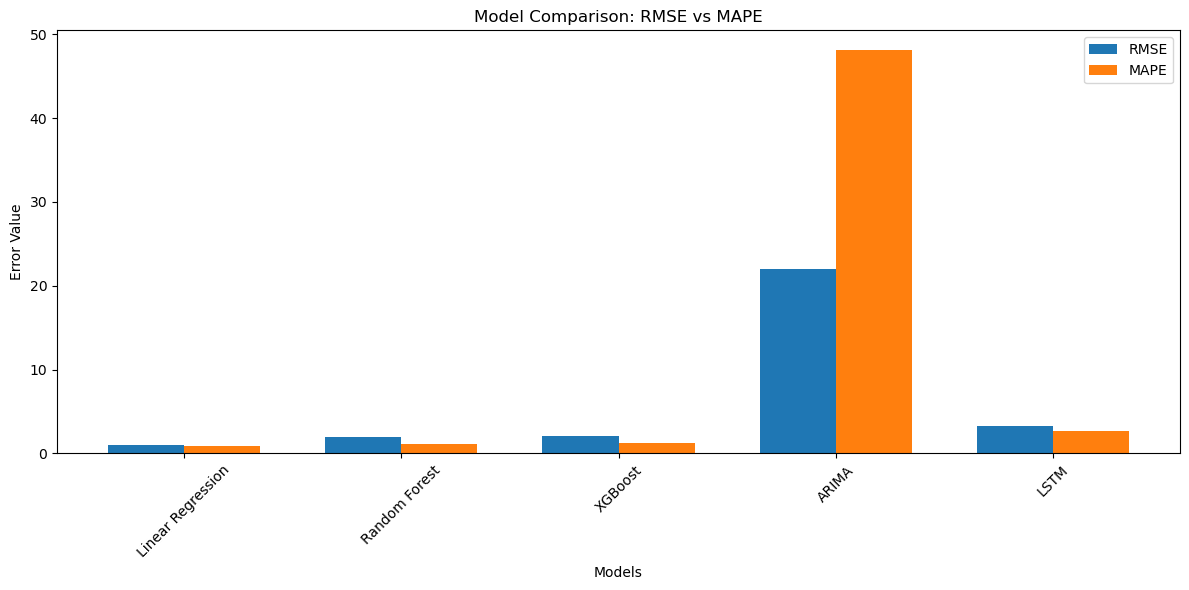

In [30]:
# Comparison Plot (RMSE & MAPE)

import numpy as np
import matplotlib.pyplot as plt

models = results["Model"]
rmse = results["RMSE"]
mape = results["MAPE"]

x = np.arange(len(models))  # model positions
width = 0.35  # bar width

plt.figure(figsize=(12,6))

plt.bar(x - width/2, rmse, width, label="RMSE")
plt.bar(x + width/2, mape, width, label="MAPE")

plt.xticks(x, models, rotation=45)
plt.title("Model Comparison: RMSE vs MAPE")
plt.xlabel("Models")
plt.ylabel("Error Value")
plt.legend()

plt.tight_layout()
plt.show()

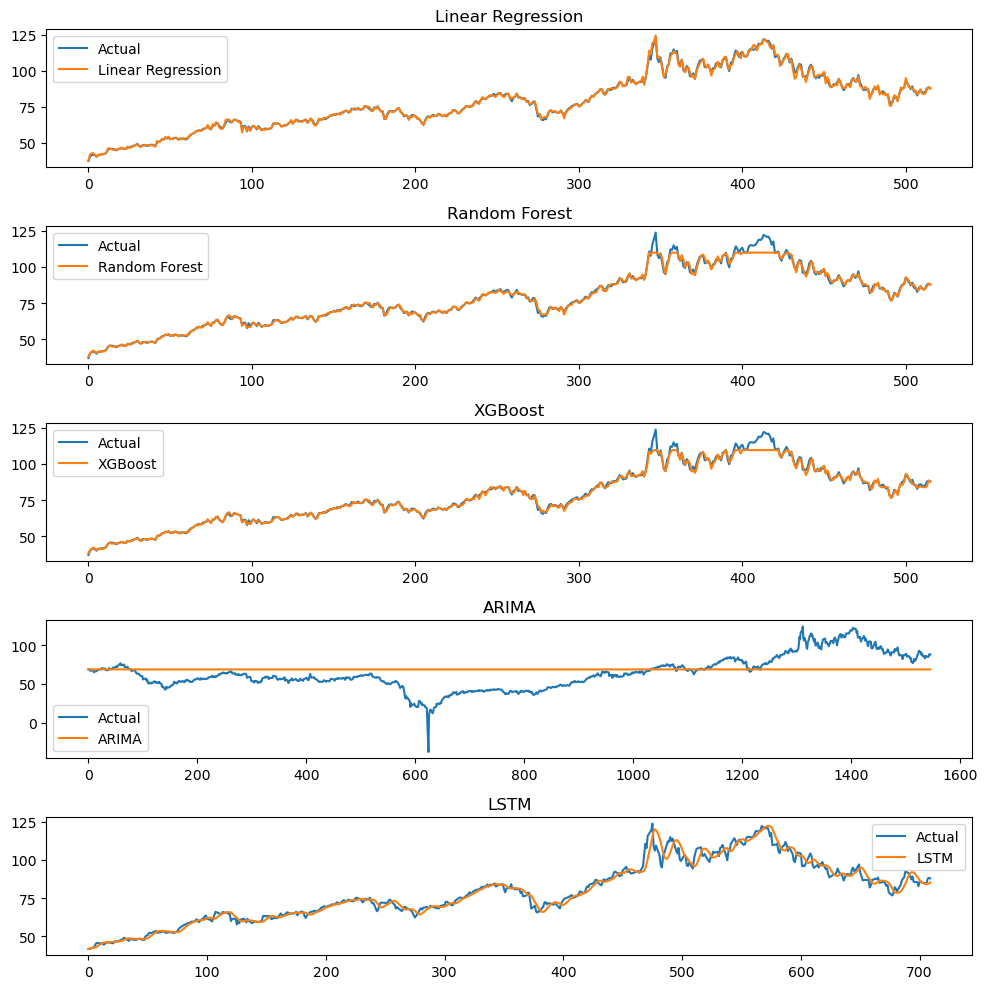

In [31]:
# Subplot Comparison

fig, axes = plt.subplots(5, 1, figsize=(10,10))

# Linear Regression
axes[0].plot(y_test.values, label="Actual")
axes[0].plot(lr_pred, label="Linear Regression")
axes[0].set_title("Linear Regression")
axes[0].legend()

# Random Forest
axes[1].plot(y_test.values, label="Actual")
axes[1].plot(rf_pred, label="Random Forest")
axes[1].set_title("Random Forest")
axes[1].legend()

# XGBoost
axes[2].plot(y_test.values, label="Actual")
axes[2].plot(xgb_pred, label="XGBoost")
axes[2].set_title("XGBoost")
axes[2].legend()

# ARIMA
axes[3].plot(test_arima.values, label="Actual")
axes[3].plot(arima_pred.values, label="ARIMA")
axes[3].set_title("ARIMA")
axes[3].legend()

# LSTM
axes[4].plot(y_test_actual, label="Actual")
axes[4].plot(lstm_pred, label="LSTM")
axes[4].set_title("LSTM")
axes[4].legend()

plt.tight_layout()
plt.show()

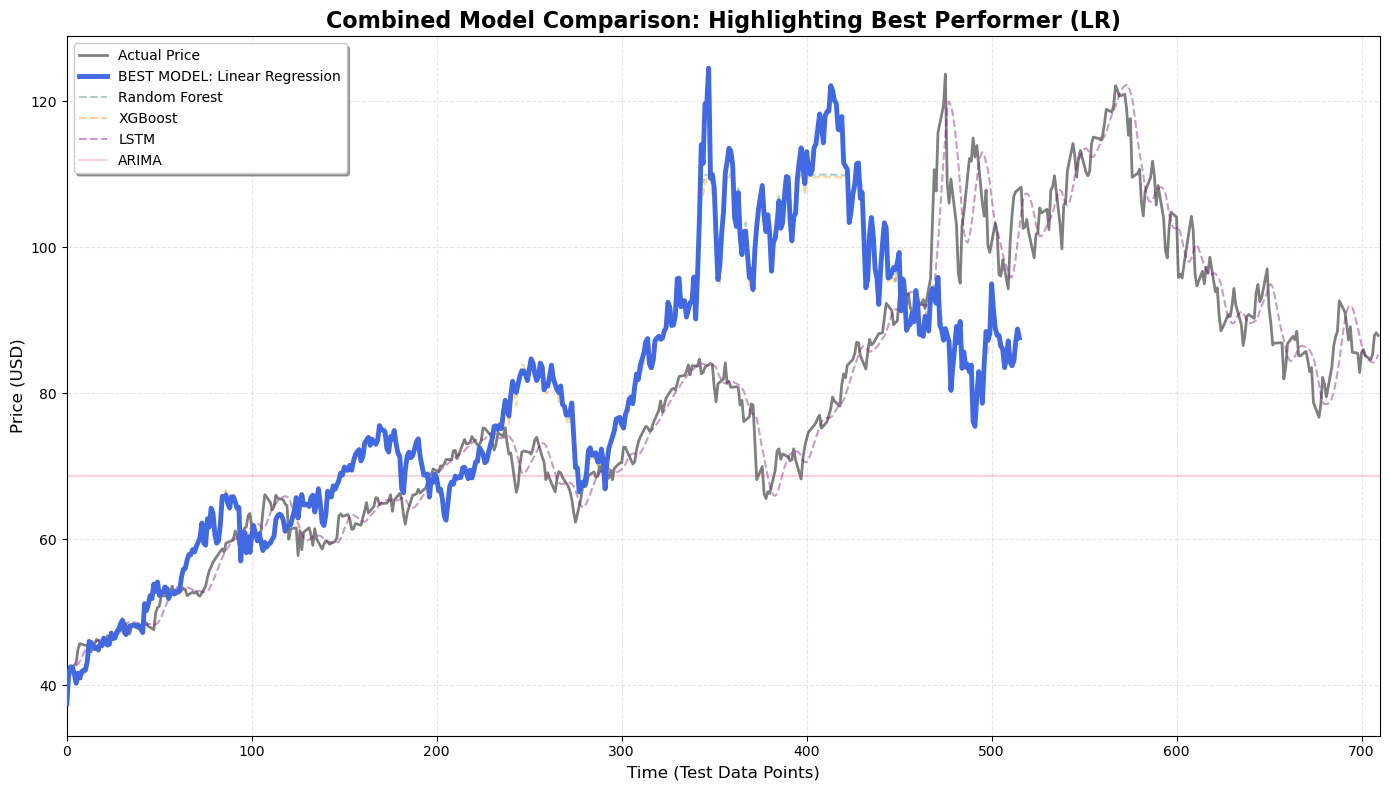

In [32]:
# Actual vs. Predicted  Visualization

import matplotlib.pyplot as plt
import numpy as np

def plot_highlighted_comparison_fixed(y_test, lr_pred, rf_pred, xgb_pred, arima_pred, lstm_pred, y_test_actual):
    plt.figure(figsize=(14, 8))

    # IMPORTANT: We convert everything to numpy arrays to strip away the 
    # date index that is causing the 1970/2020 squashing issue.
    actual_data = np.array(y_test_actual).flatten()
    
    # 1. Plot Actual Price
    plt.plot(actual_data, label='Actual Price', color='black', linewidth=2, alpha=0.5)

    # 2. HIGHLIGHT BEST MODEL: Linear Regression
    # Ensure lr_pred is a flat array
    plt.plot(np.array(lr_pred).flatten(), label='BEST MODEL: Linear Regression', 
             color='royalblue', linewidth=3.5, linestyle='-', zorder=10)

    # 3. Plot other models (Thinner, dashed)
    plt.plot(np.array(rf_pred).flatten(), label='Random Forest', color='seagreen', linestyle='--', alpha=0.4)
    plt.plot(np.array(xgb_pred).flatten(), label='XGBoost', color='darkorange', linestyle='--', alpha=0.4)
    plt.plot(np.array(lstm_pred).flatten(), label='LSTM', color='purple', linestyle='--', alpha=0.4)
    plt.plot(np.array(arima_pred).flatten(), label='ARIMA', color='crimson', alpha=0.2)

    # Formatting
    plt.title('Combined Model Comparison: Highlighting Best Performer (LR)', fontsize=16, fontweight='bold')
    plt.xlabel('Time (Test Data Points)', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    
    # Force the X-axis to start at 0 and end at the number of data points
    plt.xlim(0, len(actual_data))
    
    plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
    plt.grid(True, which='both', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run this one instead:
plot_highlighted_comparison_fixed(y_test, lr_pred, rf_pred, xgb_pred, arima_pred, lstm_pred, y_test_actual)

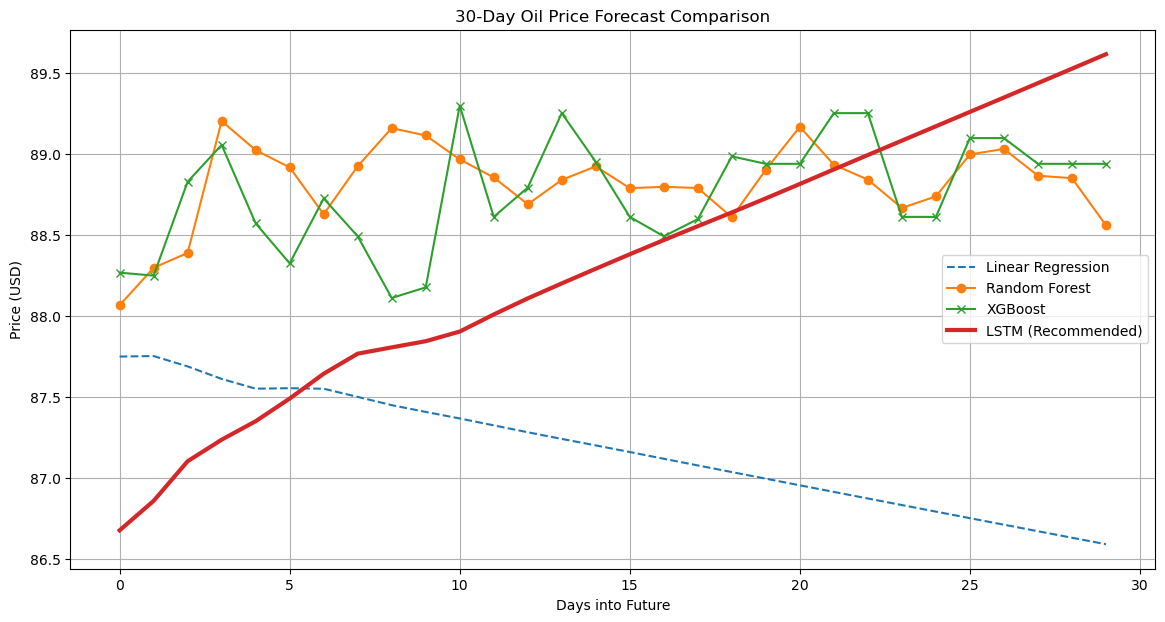

In [33]:
# 30-Day Future plot of all 4 model except arima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Load data from "Crude oil.csv"
df = pd.read_csv("D:\Projects\Oil price prediction\Crude oil - Crude oil.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')
data = df['Close/Last'].values.reshape(-1, 1)

# Scaler for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Helper function to create sequences for forecasting
def create_forecast(model, last_sequence, days=30, is_rnn=False):
    forecast = []
    current_seq = last_sequence.copy()
    
    for _ in range(days):
        if is_rnn:
            pred = model.predict(current_seq.reshape(1, 10, 1), verbose=0)[0]
        else:
            pred = model.predict(current_seq.reshape(1, -1))[0]
        
        forecast.append(pred)
        current_seq = np.append(current_seq[1:], pred)
    return forecast

# --- Model Training (Simplified for 10-day window) ---
window = 10
X, y = [], []
for i in range(window, len(data)):
    X.append(scaled_data[i-window:i, 0])
    y.append(scaled_data[i, 0])
X, y = np.array(X), np.array(y)

# 1. Linear Regression
lr = LinearRegression().fit(X, y)
# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100).fit(X, y)
# 3. XGBoost
xgb = XGBRegressor().fit(X, y)
# 4. LSTM
X_lstm = X.reshape(X.shape[0], X.shape[1], 1)
lstm = Sequential([
    LSTM(50, return_sequences=False, input_shape=(window, 1)),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_lstm, y, epochs=5, batch_size=32, verbose=0)

# Generate 30-Day Forecasts
last_win = scaled_data[-window:]
lr_f = scaler.inverse_transform(np.array(create_forecast(lr, last_win)).reshape(-1, 1))
rf_f = scaler.inverse_transform(np.array(create_forecast(rf, last_win)).reshape(-1, 1))
xgb_f = scaler.inverse_transform(np.array(create_forecast(xgb, last_win)).reshape(-1, 1))
lstm_f = scaler.inverse_transform(np.array(create_forecast(lstm, last_win, is_rnn=True)).reshape(-1, 1))

# --- Visualization ---
plt.figure(figsize=(14, 7))
plt.plot(range(30), lr_f, label='Linear Regression', linestyle='--')
plt.plot(range(30), rf_f, label='Random Forest', marker='o')
plt.plot(range(30), xgb_f, label='XGBoost', marker='x')
plt.plot(range(30), lstm_f, label='LSTM (Recommended)', linewidth=3)
plt.title("30-Day Oil Price Forecast Comparison")
plt.xlabel("Days into Future")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

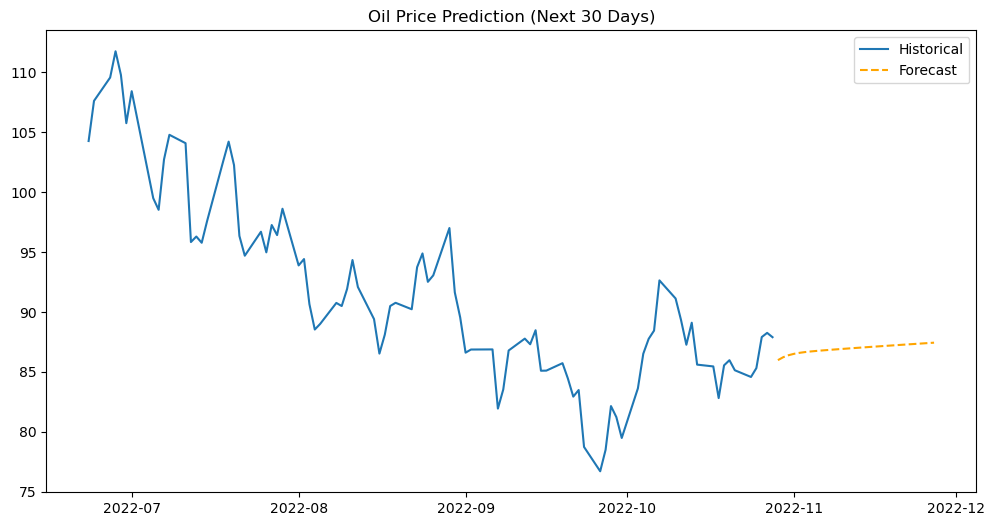

In [34]:
# 30-Day Future plot of the LSTM 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# Identifies the correct column Based on your error, we switch 'Price' to 'Close/Last'
target_col = 'Close/Last' 

# Prepares the last 60 days of data
n_steps = 60 
last_sequence = df[target_col].values[-n_steps:].reshape(-1, 1)
last_sequence_scaled = scaler.transform(last_sequence)

# Predicts the next 30 days
predictions = []
current_input = last_sequence_scaled.reshape((1, n_steps, 1))

for _ in range(30):
    # Predict 1 step ahead
    next_pred = model_lstm.predict(current_input, verbose=0)
    predictions.append(next_pred[0])
    
    # Slide the window: Drop the oldest, add the newest prediction
    next_pred_reshaped = next_pred.reshape(1, 1, 1)
    current_input = np.concatenate([current_input[:, 1:, :], next_pred_reshaped], axis=1)

# Convert back to original price scale
forecast_prices = scaler.inverse_transform(predictions)

# Create dates and Plot
last_date = df.index[-1]
forecast_dates = [last_date + timedelta(days=i) for i in range(1, 31)]

plt.figure(figsize=(12, 6))
plt.plot(df.index[-90:], df[target_col].tail(90), label='Historical')
plt.plot(forecast_dates, forecast_prices, label='Forecast', color='orange', linestyle='--')
plt.title('Oil Price Prediction (Next 30 Days)')
plt.legend()
plt.show()

In [35]:
# saving model 
import os
import joblib

# Create folder if it doesn't exist
os.makedirs("model", exist_ok=True)

# 1. Save LSTM model
model_lstm.save("model/lstm_model.keras")

# 2. Save scaler (IMPORTANT: use your MinMaxScaler for LSTM)
joblib.dump(scaler_lstm, "model/scaler.pkl")

# 3. Save config (window size + feature info)
config = {
    "window_size": 60,
    "feature": "Price"
}
joblib.dump(config, "model/config.pkl")

print("Model saved successfully!")

Model saved successfully!
